# Frigg S2S — Development Playground

Run any section independently to inspect a specific layer of the pipeline.
No section depends on output from a previous one (models are trained inline).

**Sections**
1. Setup & data load
2. Dataset health check
3. EDA — price profiles and market structure
4. Feature distributions and correlations
5. Model training
6. Validation metrics — what each number means
7. CQR calibration — before vs after
8. Feature importance — cross-zone comparison
9. Error analysis — where the model fails and why
10. Eval-window forecast (May 8–9 2026)
11. Long-term seasonal forecast (2-year)


## 1 · Setup & data load

In [1]:
%pip install -q lightgbm scikit-learn pandas numpy matplotlib holidays pyarrow entsoe-py

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings; warnings.filterwarnings("ignore")
import os
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import holidays as hdays

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
ZONE_COLORS = {"DE-LU": "#1565C0", "ES": "#BF360C"}


In [3]:
# ── Paths & constants ──────────────────────────────────────────────────────
ROOT      = Path("..").resolve()
DATA_PATH = ROOT / "data" / "processed" / "final_dataset.parquet"
OUT_PATH  = ROOT / "predictions.csv"

FEATURES = [
    "load", "wind_generation", "solar_generation", "hydro_generation",
    "temperature", "wind_speed", "solar_radiation",
    "gas_price", "carbon_price",
    "residual_load", "renewable_penetration",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos", "week_sin", "week_cos",
    "is_holiday",
    "lag_1", "lag_24", "lag_168",
    "price_roll_24h", "price_roll_168h",
]
TARGET    = "price"
ZONES     = ["DE-LU", "ES"]
QUANTILES = [0.025, 0.45, 0.975]
TRAIN_END = "2025-01-01"
VAL_END   = "2026-01-01"
CAL_END   = "2026-05-08"

LGB_BASE = dict(
    objective="quantile", metric="quantile",
    n_estimators=3000, learning_rate=0.05,
    num_leaves=127, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    n_jobs=-1, verbose=-1,
)


In [4]:
df = pd.read_parquet(DATA_PATH)

# Silently drop any features not in dataset (e.g. net_imports before ENTSOE rerun)
FEATURES = [f for f in FEATURES if f in df.columns]
missing = {"net_imports", "load", "wind_generation", "solar_generation"} - set(df.columns)
if missing:
    print(f"⚠  Missing features (re-run pipeline to populate): {missing}")

ts = df.index.get_level_values("timestamp")
print(f"Dataset   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Zones     : {df.index.get_level_values('zone').unique().tolist()}")
print(f"Date range: {ts.min().date()} → {ts.max().date()}")
print(f"Features  : {len(FEATURES)} active")
df.head(3)


Dataset   : 92,712 rows × 31 columns
Zones     : ['DE-LU', 'ES']
Date range: 2021-01-11 → 2026-05-05
Features  : 25 active


price  wind_generation  solar_generation  \
timestamp                 zone                                              
2021-01-11 00:00:00+00:00 DE-LU  44.74       18141.3250            1.0925   
                          ES     53.19       10796.0000           45.0000   
2021-01-11 01:00:00+00:00 DE-LU  45.06       19222.6375            1.0500   

                                 hydro_generation        load  temperature  \
timestamp                 zone                                               
2021-01-11 00:00:00+00:00 DE-LU          1224.760  52576.1200         -3.0   
                          ES             4267.000  25365.0000         -3.1   
2021-01-11 01:00:00+00:00 DE-LU          1158.815  52170.2225         -3.4   

                                 wind_speed  solar_radiation  gas_price  \
timestamp                 zone                                            
2021-01-11 00:00:00+00:00 DE-LU        1.36              0.0     22.125   
                          ES           3.01              0.0     22.125   
2021-01-11 01:00:00+00:00 DE-LU        1.22              0.0     22.125   

                                 carbon_price  ...  month_sin  month_cos  \
timestamp                 zone                 ...                         
2021-01-11 00:00:00+00:00 DE-LU     17.903812  ...        0.0        1.0   
                          ES        17.903812  ...        0.0        1.0   
2021-01-11 01:00:00+00:00 DE-LU     17.903812  ...        0.0        1.0   

                                 week_sin  week_cos  lag_1  lag_24  lag_168  \
timestamp                 zone                                                
2021-01-11 00:00:00+00:00 DE-LU  0.120537  0.992709  44.90   51.79    24.82   
                          ES     0.120537  0.992709  58.25   55.75    47.01   
2021-01-11 01:00:00+00:00 DE-LU  0.120537  0.992709  44.74   50.58    24.65   

                                 price_roll_24h  price_roll_168h  is_holiday  
timestamp                 zone                                                
2021-01-11 00:00:00+00:00 DE-LU       51.464583        59.751905           0  
                          ES          66.007917        75.633095           0  
2021-01-11 01:00:00+00:00 DE-LU       51.234583        59.873393           0  

[3 rows x 31 columns]

## 2 · Dataset health check

Verify the pipeline produced clean output: no NaNs, continuous timestamps, sane value ranges.


In [5]:
print("=== NaN counts per column ===")
nan_counts = df.isnull().sum()
print(nan_counts[nan_counts > 0].to_string() if nan_counts.any() else "  None — clean ✓")

print()
print("=== Timestamp continuity per zone ===")
for zone in ZONES:
    zdf  = df.xs(zone, level="zone").sort_index()
    diffs = zdf.index.to_series().diff().dropna()
    gaps  = diffs[diffs > pd.Timedelta("1h")]
    print(f"  {zone}: {len(zdf):,} rows  |  gaps > 1h: {len(gaps)}")
    if len(gaps):
        print(gaps.head(3).to_string())

print()
print("=== Value ranges ===")
check_cols = ["price", "load", "wind_generation", "solar_generation", "gas_price"]
check_cols = [c for c in check_cols if c in df.columns]
df[check_cols].describe().round(1)


=== NaN counts per column ===
net_imports    1

=== Timestamp continuity per zone ===
  DE-LU: 46,372 rows  |  gaps > 1h: 10
timestamp
2021-06-30 22:00:00+00:00   0 days 22:00:00
2021-12-28 23:00:00+00:00   0 days 22:00:00
2022-06-27 22:00:00+00:00   0 days 22:00:00
  ES: 46,340 rows  |  gaps > 1h: 11
timestamp
2021-06-30 22:00:00+00:00   0 days 22:00:00
2021-12-28 23:00:00+00:00   0 days 22:00:00
2022-06-27 22:00:00+00:00   0 days 22:00:00

=== Value ranges ===


,price,load,wind_generation,solar_generation,gas_price
count,92712.0,92712.0,92712.0,92712.0,92712.0
mean,106.8,40941.8,10955.2,5696.4,57.4
std,86.1,15855.1,9287.0,8647.0,45.5
min,-500.0,0.0,0.0,0.0,15.5
25%,58.3,26959.0,4398.0,17.0,32.0
50%,93.8,36401.7,8050.9,634.0,39.3
75%,132.9,54916.0,14114.0,9369.2,65.0
max,936.3,82115.7,53615.2,54169.0,339.2


In [6]:
# Train / Val / Cal split sizes
print("=== Dataset split ===")
for zone in ZONES:
    zdf   = df.xs(zone, level="zone").sort_index()
    train = zdf[zdf.index < TRAIN_END]
    val   = zdf[(zdf.index >= TRAIN_END) & (zdf.index < VAL_END)]
    cal   = zdf[(zdf.index >= VAL_END)   & (zdf.index < CAL_END)]
    print(f"  {zone}  train={len(train):,}  val={len(val):,}  cal={len(cal):,}")


=== Dataset split ===
  DE-LU  train=34,656  val=8,718  cal=2,998
  ES  train=34,656  val=8,686  cal=2,998


## 3 · EDA — price profiles and market structure

Key things to look for:
- **Left tail (negative prices)**: DE-LU has a much heavier left tail — solar + wind surplus on
  low-demand hours/holidays pushes prices below zero. ES rarely goes negative (isolated grid,
  less renewable surplus reaching the market).
- **Hourly profile**: both zones show morning ramp + midday solar dip + evening peak.
  The solar dip is deeper and earlier in ES (higher irradiance, further south).
- **Monthly seasonality**: DE-LU peaks in winter (heating demand, low solar). ES peaks in
  summer (cooling demand, AC load). Opposite drivers.


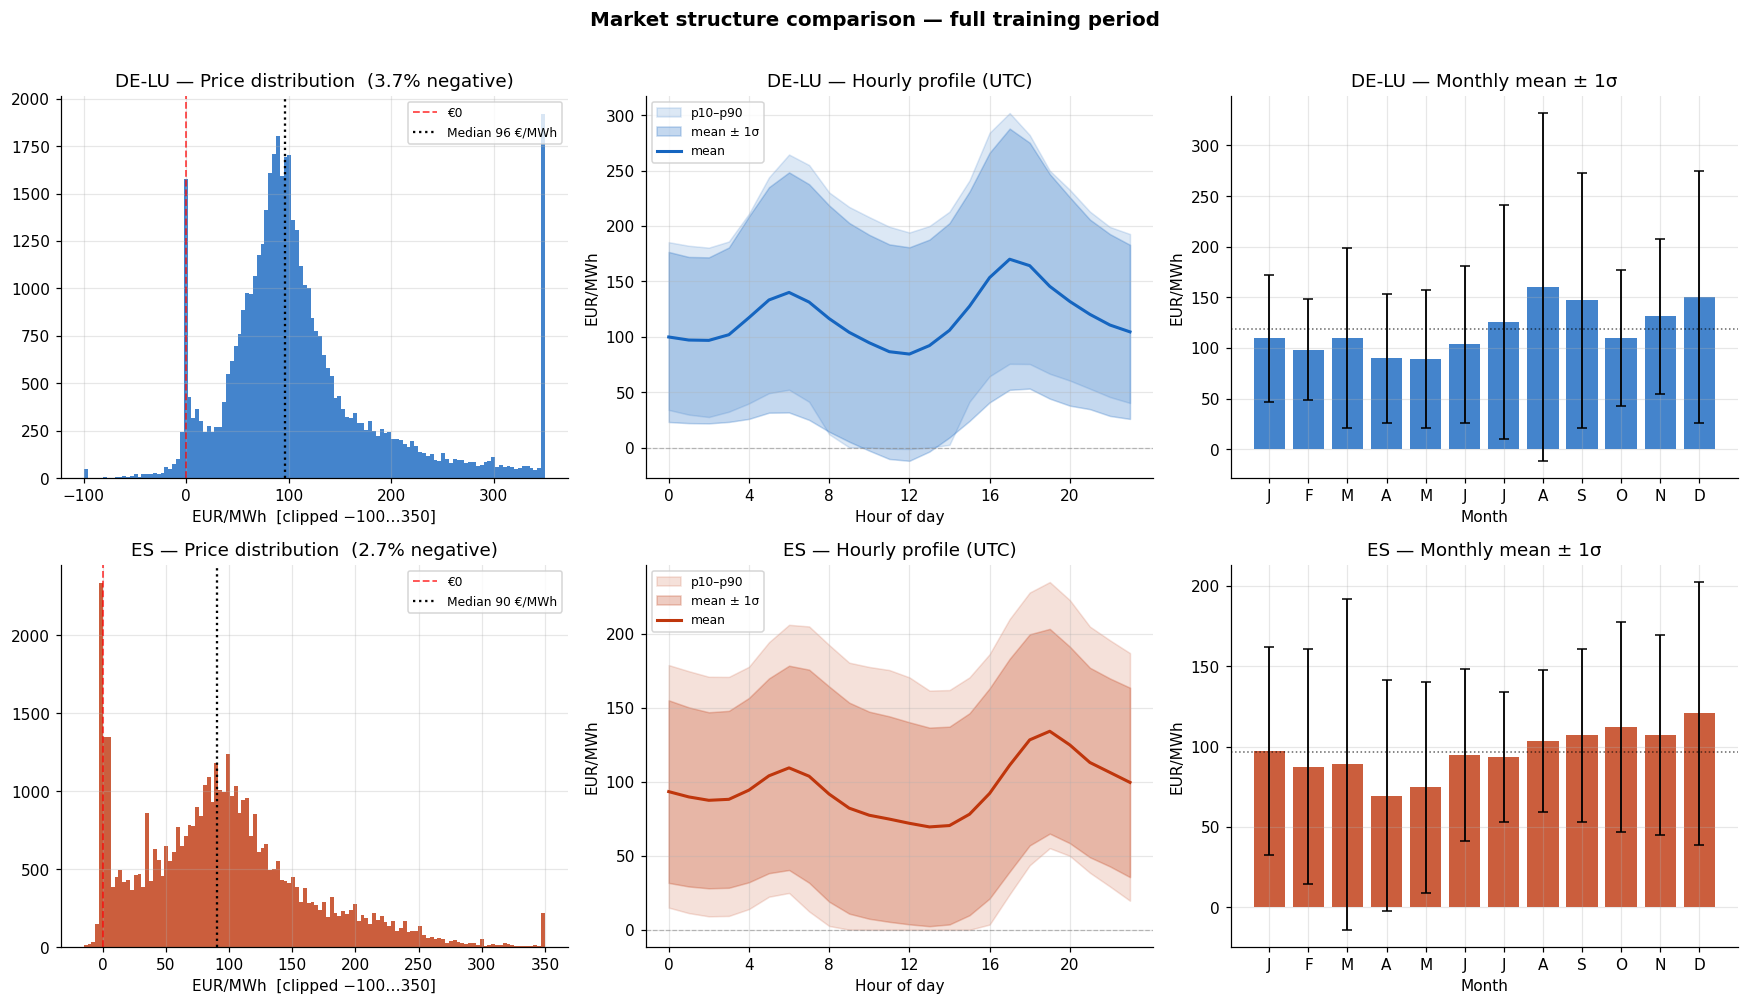

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, zone in enumerate(ZONES):
    zdf = df.xs(zone, level="zone")
    c   = ZONE_COLORS[zone]

    # Distribution (clipped for readability)
    ax = axes[i, 0]
    clipped = zdf["price"].clip(-100, 350)
    clipped.hist(bins=120, ax=ax, color=c, alpha=0.8, edgecolor="none")
    ax.axvline(0,                  color="red",   lw=1.2, linestyle="--", alpha=0.7, label="€0")
    ax.axvline(zdf["price"].median(), color="black", lw=1.5, linestyle=":",
               label=f"Median {zdf['price'].median():.0f} €/MWh")
    neg_pct = (zdf["price"] < 0).mean() * 100
    ax.set_title(f"{zone} — Price distribution  ({neg_pct:.1f}% negative)")
    ax.set_xlabel("EUR/MWh  [clipped −100…350]")
    ax.legend(fontsize=8)

    # Hourly profile
    ax = axes[i, 1]
    hp = zdf.groupby(zdf.index.hour)["price"].agg(["mean", "std", lambda x: x.quantile(0.1), lambda x: x.quantile(0.9)])
    hp.columns = ["mean", "std", "p10", "p90"]
    ax.fill_between(hp.index, hp["p10"], hp["p90"], alpha=0.15, color=c, label="p10–p90")
    ax.fill_between(hp.index, hp["mean"]-hp["std"], hp["mean"]+hp["std"], alpha=0.25, color=c, label="mean ± 1σ")
    ax.plot(hp.index, hp["mean"], lw=2, color=c, label="mean")
    ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.5)
    ax.set_title(f"{zone} — Hourly profile (UTC)")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("EUR/MWh")
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=8)

    # Monthly seasonality
    ax = axes[i, 2]
    mp  = zdf.groupby(zdf.index.month)["price"].agg(["mean", "std"])
    ax.bar(mp.index, mp["mean"], color=c, alpha=0.8, edgecolor="none")
    ax.errorbar(mp.index, mp["mean"], yerr=mp["std"], fmt="none", color="black", capsize=3, lw=1.2)
    ax.axhline(mp["mean"].mean(), color="black", lw=1, linestyle=":", alpha=0.6)
    ax.set_title(f"{zone} — Monthly mean ± 1σ")
    ax.set_xlabel("Month")
    ax.set_ylabel("EUR/MWh")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])

plt.suptitle("Market structure comparison — full training period", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


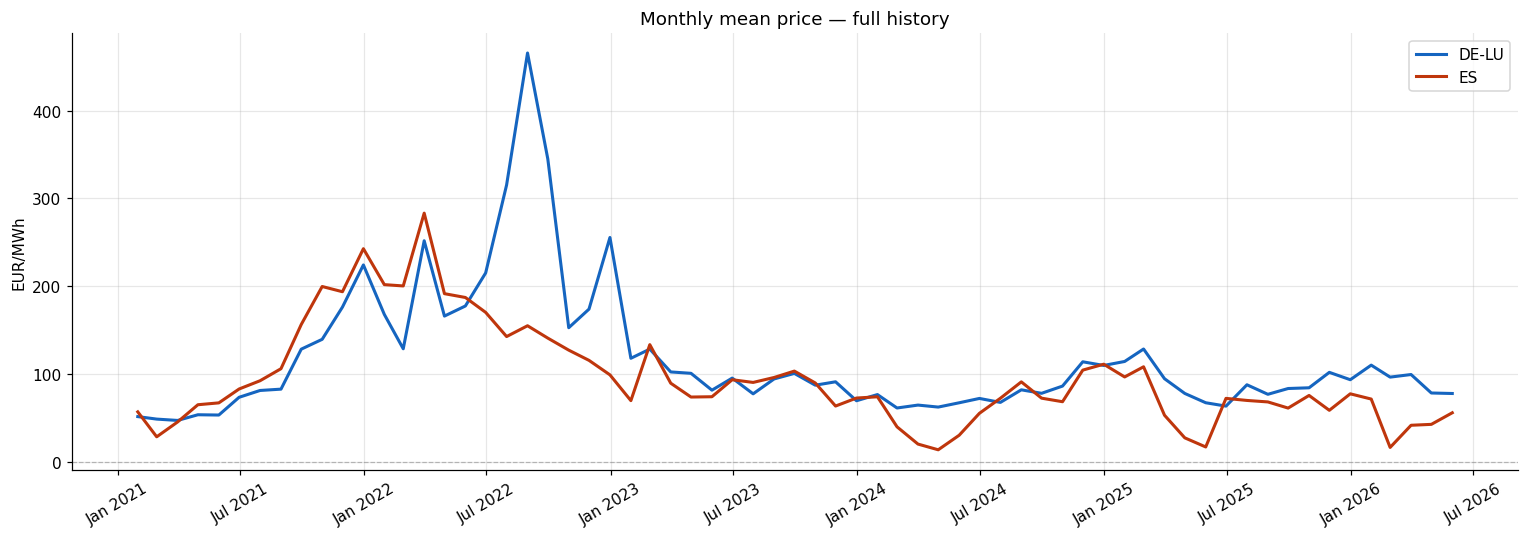

In [8]:
# Year-over-year price level — spot structural shifts (energy crisis 2021-22, normalisation 2023-24)
fig, ax = plt.subplots(figsize=(14, 5))
for zone in ZONES:
    zdf = df.xs(zone, level="zone")
    annual = zdf["price"].resample("ME").mean()
    ax.plot(annual.index, annual.values, lw=2, label=zone, color=ZONE_COLORS[zone])

ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.5)
ax.set_title("Monthly mean price — full history")
ax.set_ylabel("EUR/MWh")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.show()


## 4 · Feature distributions and correlations

Key relationships to verify:
- `lag_24` and `lag_168` should have the strongest linear correlation with price (~0.7–0.85)
- `wind_generation` negative correlation with price (more wind → lower price)
- `solar_generation` strong negative correlation in daytime hours
- `load` positive correlation (more demand → higher price)
- `net_imports` (if available): negative correlation expected for DE-LU
  (importing = surplus elsewhere → price pressure down)


In [9]:
# Correlation table — price vs each feature
corr_features = [f for f in [
    "load", "wind_generation", "solar_generation", "hydro_generation",
    "gas_price", "carbon_price", "net_imports",
    "lag_1", "lag_24", "lag_168", "residual_load", "renewable_penetration",
    "temperature",
] if f in df.columns]

print("Pearson correlation with price:")
print(f"{'Feature':<28} {'DE-LU':>8} {'ES':>8}")
print("-" * 46)
for feat in corr_features:
    r = {}
    for zone in ZONES:
        zdf = df.xs(zone, level="zone")
        r[zone] = zdf[[feat, "price"]].dropna().corr().iloc[0, 1]
    print(f"  {feat:<26} {r['DE-LU']:>+8.3f} {r['ES']:>+8.3f}")


Pearson correlation with price:
Feature                         DE-LU       ES
----------------------------------------------
  load                         +0.193   +0.226
  wind_generation              -0.320   -0.178
  solar_generation             -0.210   -0.312
  hydro_generation             +0.263   -0.070
  gas_price                    +0.768   +0.554
  carbon_price                 +0.235   +0.283
  net_imports                  +0.094   +0.120
  lag_1                        +0.975   +0.978
  lag_24                       +0.857   +0.899
  lag_168                      +0.753   +0.791
  residual_load                +0.539   +0.551
  renewable_penetration        -0.503   -0.503
  temperature                  -0.004   -0.054


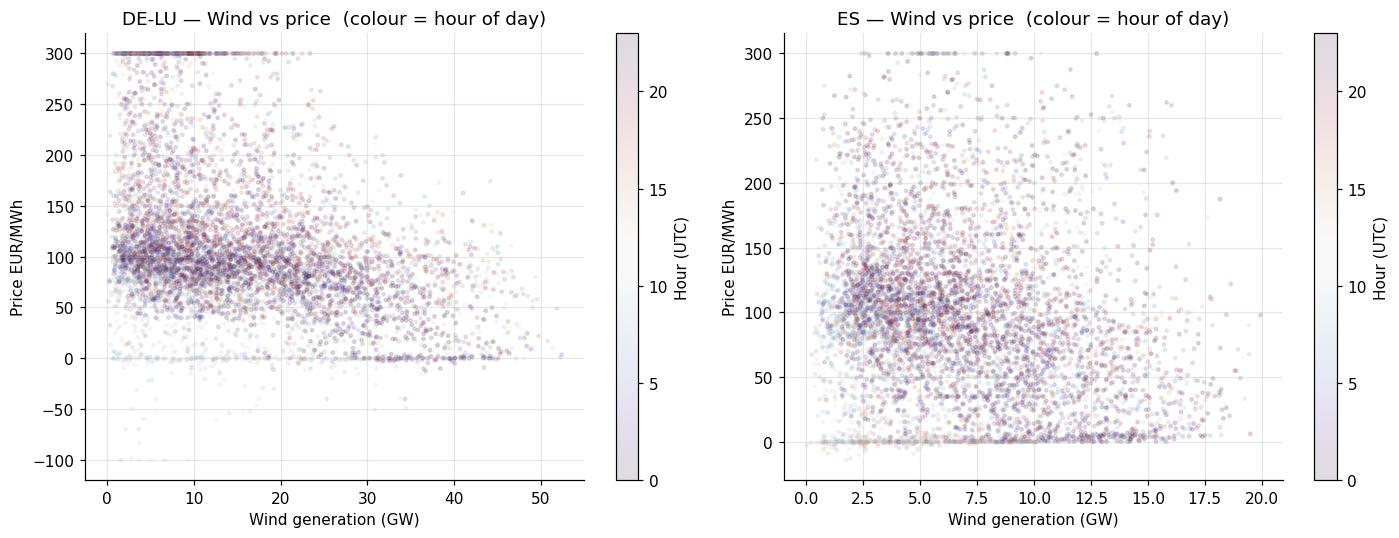

In [10]:
# Wind vs price scatter — shows the non-linear relationship
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, zone in enumerate(ZONES):
    zdf    = df.xs(zone, level="zone")
    sample = zdf.sample(min(6000, len(zdf)), random_state=42)
    ax     = axes[i]
    sc = ax.scatter(
        sample["wind_generation"] / 1e3,
        sample["price"].clip(-100, 300),
        c=sample.index.hour, cmap="twilight_shifted",
        alpha=0.15, s=5,
    )
    ax.set_xlabel("Wind generation (GW)")
    ax.set_ylabel("Price EUR/MWh")
    ax.set_title(f"{zone} — Wind vs price  (colour = hour of day)")
    plt.colorbar(sc, ax=ax, label="Hour (UTC)")

plt.tight_layout()
plt.show()


## 5 · Model training

Three quantile regressors per zone: q=0.025, q=0.45, q=0.975.

**Why q=0.45 for p50?**
The scoring metric is pinball loss at q=0.45, not q=0.50. Training the "median" at
q=0.45 means the model is calibrated to predict the 45th percentile — 45% of actual
prices fall below it. Because q < 0.5, overestimation is penalised ~1.22× more than
underestimation. The model learns a slight downward bias by design.

**Early stopping** monitors the validation pinball on each quantile independently.
`best_iteration_` tells you how many trees were actually used (if much less than
`n_estimators=3000`, the model converged early and is not overfitting).


In [11]:
def pinball(y_true, y_pred, q):
    return float(mean_pinball_loss(y_true, y_pred, alpha=q))

def train_zone(zdf, zone):
    train = zdf[zdf.index <  TRAIN_END]
    val   = zdf[(zdf.index >= TRAIN_END) & (zdf.index < VAL_END)]
    X_tr, y_tr = train[FEATURES].dropna(), train.loc[train[FEATURES].dropna().index, TARGET]
    X_va, y_va = val[FEATURES].dropna(),   val.loc[val[FEATURES].dropna().index,   TARGET]

    print(f"  {zone}  train={len(X_tr):,}  val={len(X_va):,}  features={len(FEATURES)}")
    qmodels, val_preds = {}, {}

    for q in QUANTILES:
        m = lgb.LGBMRegressor(**{**LGB_BASE, "alpha": q})
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        qmodels[q]   = m
        val_preds[q] = m.predict(X_va)
        print(f"    q={q:.3f}  trees={m.best_iteration_:,}  pinball={pinball(y_va.values, val_preds[q], q):.4f}")

    return qmodels, {"preds": val_preds, "actual": y_va, "X": X_va}

print("Training models (expect ~60s)...")
all_models, all_val = {}, {}
for zone in ZONES:
    print(f"\n[{zone}]")
    zdf = df.xs(zone, level="zone").sort_index()
    qmodels, val = train_zone(zdf, zone)
    all_models[zone] = qmodels
    all_val[zone]    = val
print("\nDone.")


Training models (expect ~60s)...

[DE-LU]
  DE-LU  train=34,656  val=8,718  features=25
    q=0.025  trees=187  pinball=0.7372
    q=0.450  trees=1,259  pinball=3.8925
    q=0.975  trees=182  pinball=1.1301

[ES]
  ES  train=34,656  val=8,686  features=25
    q=0.025  trees=170  pinball=0.8341
    q=0.450  trees=1,634  pinball=3.3626
    q=0.975  trees=298  pinball=0.8584

Done.


## 6 · Validation metrics — what each number means

| Metric | What it measures | Good range |
|--------|-----------------|------------|
| **MAE p50** | Mean absolute error of the point forecast — average EUR/MWh you're off | < 10 EUR/MWh is competitive |
| **Pinball q=0.45** | The actual scoring metric — lower is better. Asymmetric: overestimation costs 1.22× more | < 4 is competitive for DE-LU |
| **Coverage p025–p975** | % of actual prices that fall inside your 95% interval | Should be ~95% after CQR |
| **Band width** | Average EUR/MWh width of the 95% interval — narrower = more confident | Depends on market volatility |
| **Naive MAE** | MAE of the lag_168 baseline (same hour last week) — your model must beat this | Reference baseline |

A model can have low MAE but poor pinball if it systematically overestimates (common with q=0.5
median vs q=0.45 scoring). Low coverage means the uncertainty bands are too narrow (overconfident).
High coverage with wide bands means you're being conservative — CQR finds the right balance.


In [12]:
def coverage(y, lo, hi):
    return float(((y >= lo) & (y <= hi)).mean()) * 100

rows = []
for zone in ZONES:
    y    = all_val[zone]["actual"].values
    p025 = all_val[zone]["preds"][0.025]
    p50  = all_val[zone]["preds"][0.45]
    p975 = all_val[zone]["preds"][0.975]
    lag  = all_val[zone]["X"]["lag_168"].values

    rows.append({
        "Zone"                : zone,
        "MAE p50"             : f"{np.abs(y - p50).mean():.2f}",
        "Pinball q=0.45"      : f"{pinball(y, p50, 0.45):.4f}",
        "Pinball q=0.025"     : f"{pinball(y, p025, 0.025):.4f}",
        "Pinball q=0.975"     : f"{pinball(y, p975, 0.975):.4f}",
        "Coverage p025–p975"  : f"{coverage(y, p025, p975):.1f}%",
        "Band width (mean)"   : f"{(p975-p025).mean():.1f} EUR/MWh",
        "Naive MAE (lag_168)" : f"{np.abs(y - lag).mean():.2f}",
    })

pd.DataFrame(rows).set_index("Zone").T


Zone,DE-LU,ES
MAE p50,8.09,6.66
Pinball q=0.45,3.8925,3.3626
Pinball q=0.025,0.7372,0.8341
Pinball q=0.975,1.1301,0.8584
Coverage p025–p975,89.9%,81.9%
Band width (mean),43.7 EUR/MWh,28.2 EUR/MWh
Naive MAE (lag_168),33.27,29.72


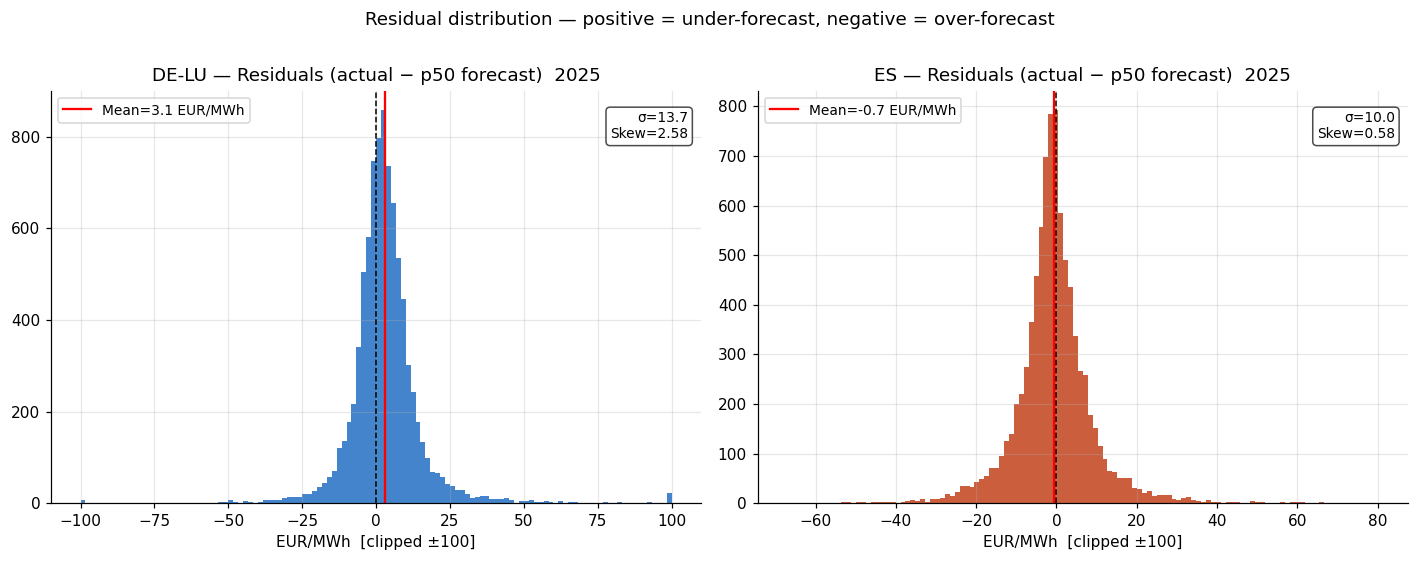

In [13]:
# Validation residuals — look for systematic bias (non-zero mean) and heavy tails
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, zone in enumerate(ZONES):
    y   = all_val[zone]["actual"].values
    p50 = all_val[zone]["preds"][0.45]
    err = y - p50          # positive = actual > forecast (under-forecast)
    ax  = axes[i]
    ax.hist(err.clip(-100, 100), bins=120, color=ZONE_COLORS[zone], alpha=0.8, edgecolor="none")
    ax.axvline(0,          color="black", lw=1,   linestyle="--")
    ax.axvline(err.mean(), color="red",   lw=1.5, label=f"Mean={err.mean():.1f} EUR/MWh")
    ax.set_title(f"{zone} — Residuals (actual − p50 forecast)  2025")
    ax.set_xlabel("EUR/MWh  [clipped ±100]")
    ax.legend(fontsize=9)
    # Annotation
    ax.text(0.98, 0.95, f"σ={err.std():.1f}\nSkew={pd.Series(err).skew():.2f}",
            transform=ax.transAxes, va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.suptitle("Residual distribution — positive = under-forecast, negative = over-forecast", y=1.01)
plt.tight_layout()
plt.show()


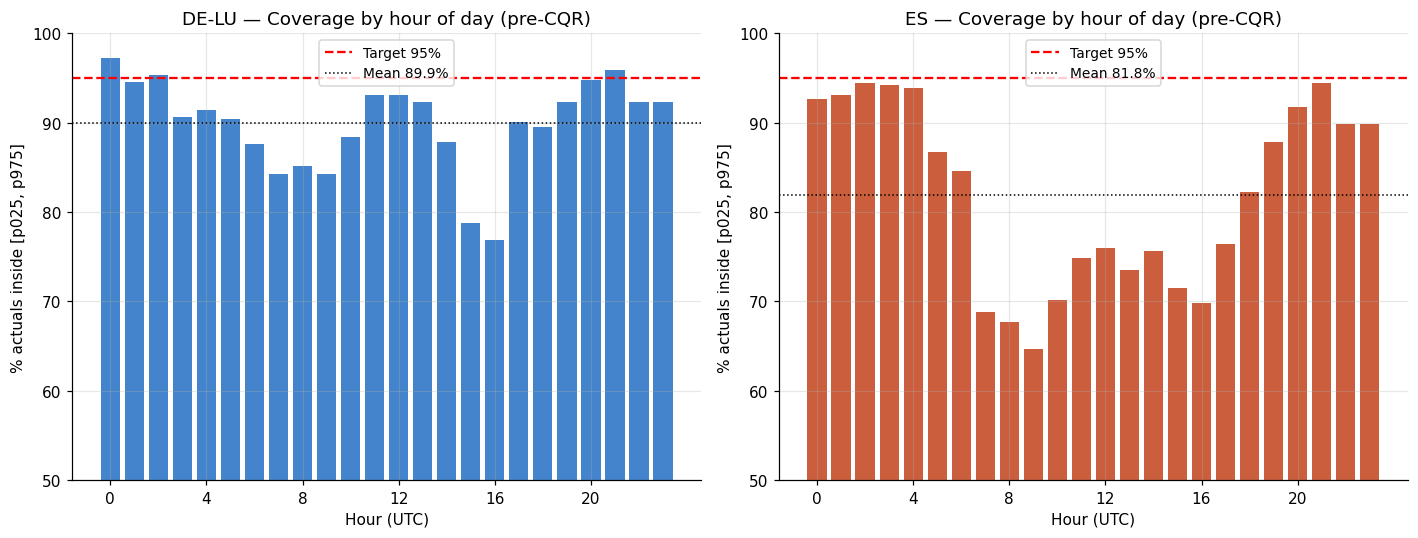

In [14]:
# Coverage diagram: fraction of actuals inside band at each hour of day
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, zone in enumerate(ZONES):
    y    = all_val[zone]["actual"]
    p025 = pd.Series(all_val[zone]["preds"][0.025], index=y.index)
    p975 = pd.Series(all_val[zone]["preds"][0.975], index=y.index)
    inside = ((y >= p025) & (y <= p975)).astype(float)
    hourly_cov = inside.groupby(inside.index.hour).mean() * 100

    ax = axes[i]
    ax.bar(hourly_cov.index, hourly_cov.values, color=ZONE_COLORS[zone], alpha=0.8, edgecolor="none")
    ax.axhline(95, color="red",   lw=1.5, linestyle="--", label="Target 95%")
    ax.axhline(hourly_cov.mean(), color="black", lw=1, linestyle=":", label=f"Mean {hourly_cov.mean():.1f}%")
    ax.set_ylim(50, 100)
    ax.set_title(f"{zone} — Coverage by hour of day (pre-CQR)")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("% actuals inside [p025, p975]")
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 7 · CQR calibration — before vs after

**How CQR works:**
1. On a held-out calibration set (Jan–May 2026), compute a nonconformity score per slot:
   `score = max(p025 − actual, actual − p975)` — positive when actual is *outside* the band
2. Find the 95th percentile of those scores: `Q_hat`
3. Inflate every future interval: `p025 − Q_hat` and `p975 + Q_hat`

This gives a **marginal coverage guarantee**: on exchangeable data, at least 95% of future
actuals will fall inside the calibrated band.

**p50 shift**: separately calibrate the p50 using the 45th percentile of residuals on the
calibration set. If the model over- or under-forecasts systematically in recent data, this
corrects it — directly improving the scoring metric.


In [15]:
def calibrate_zone(zdf, qmodels, zone):
    cal = zdf[(zdf.index >= VAL_END) & (zdf.index < CAL_END)].dropna(subset=FEATURES + [TARGET])
    if len(cal) < 50:
        print(f"  {zone}: calibration set too small — skipped"); return {"interval": 0., "p50": 0., "n": 0}

    X_cal = cal[FEATURES]
    y_cal = cal[TARGET].values
    n     = len(y_cal)

    p025 = qmodels[0.025].predict(X_cal)
    p50  = qmodels[0.45].predict(X_cal)
    p975 = qmodels[0.975].predict(X_cal)
    p025 = np.minimum(p025, p50)
    p975 = np.maximum(p975, p50)

    scores  = np.maximum(p025 - y_cal, y_cal - p975)
    q_iv    = float(np.quantile(scores, min(0.95 * (1 + 1/n), 1.0)))

    resid50 = y_cal - p50
    q_50    = float(np.quantile(resid50, min(0.45 * (1 + 1/n), 1.0)))

    cov_raw = coverage(y_cal, p025, p975)
    cov_cal = coverage(y_cal, p025 - q_iv, p975 + q_iv)
    pb_raw  = pinball(y_cal, p50, 0.45)
    pb_cal  = pinball(y_cal, p50 + q_50, 0.45)

    print(f"  {zone}  n={n:,}  interval Q_hat={q_iv:+.2f} EUR/MWh  p50 shift={q_50:+.2f}")
    print(f"    coverage  {cov_raw:.1f}% → {cov_cal:.1f}%  (target 95%)")
    print(f"    pinball   {pb_raw:.4f} → {pb_cal:.4f}  ({"+" if pb_cal>pb_raw else ""}{ pb_cal - pb_raw:.4f})")

    return {"interval": q_iv, "p50": q_50, "n": n,
            "y": y_cal, "p025": p025, "p50_raw": p50, "p975": p975}

print("CQR calibration (Jan–May 2026):")
cqr = {}
for zone in ZONES:
    zdf = df.xs(zone, level="zone").sort_index()
    cqr[zone] = calibrate_zone(zdf, all_models[zone], zone)


CQR calibration (Jan–May 2026):
  DE-LU  n=2,998  interval Q_hat=+3.37 EUR/MWh  p50 shift=+1.05
    coverage  90.9% → 95.0%  (target 95%)
    pinball   4.2609 → 4.2268  (-0.0340)
  ES  n=2,998  interval Q_hat=+3.42 EUR/MWh  p50 shift=-2.45
    coverage  76.7% → 95.0%  (target 95%)
    pinball   3.2430 → 2.9671  (-0.2759)


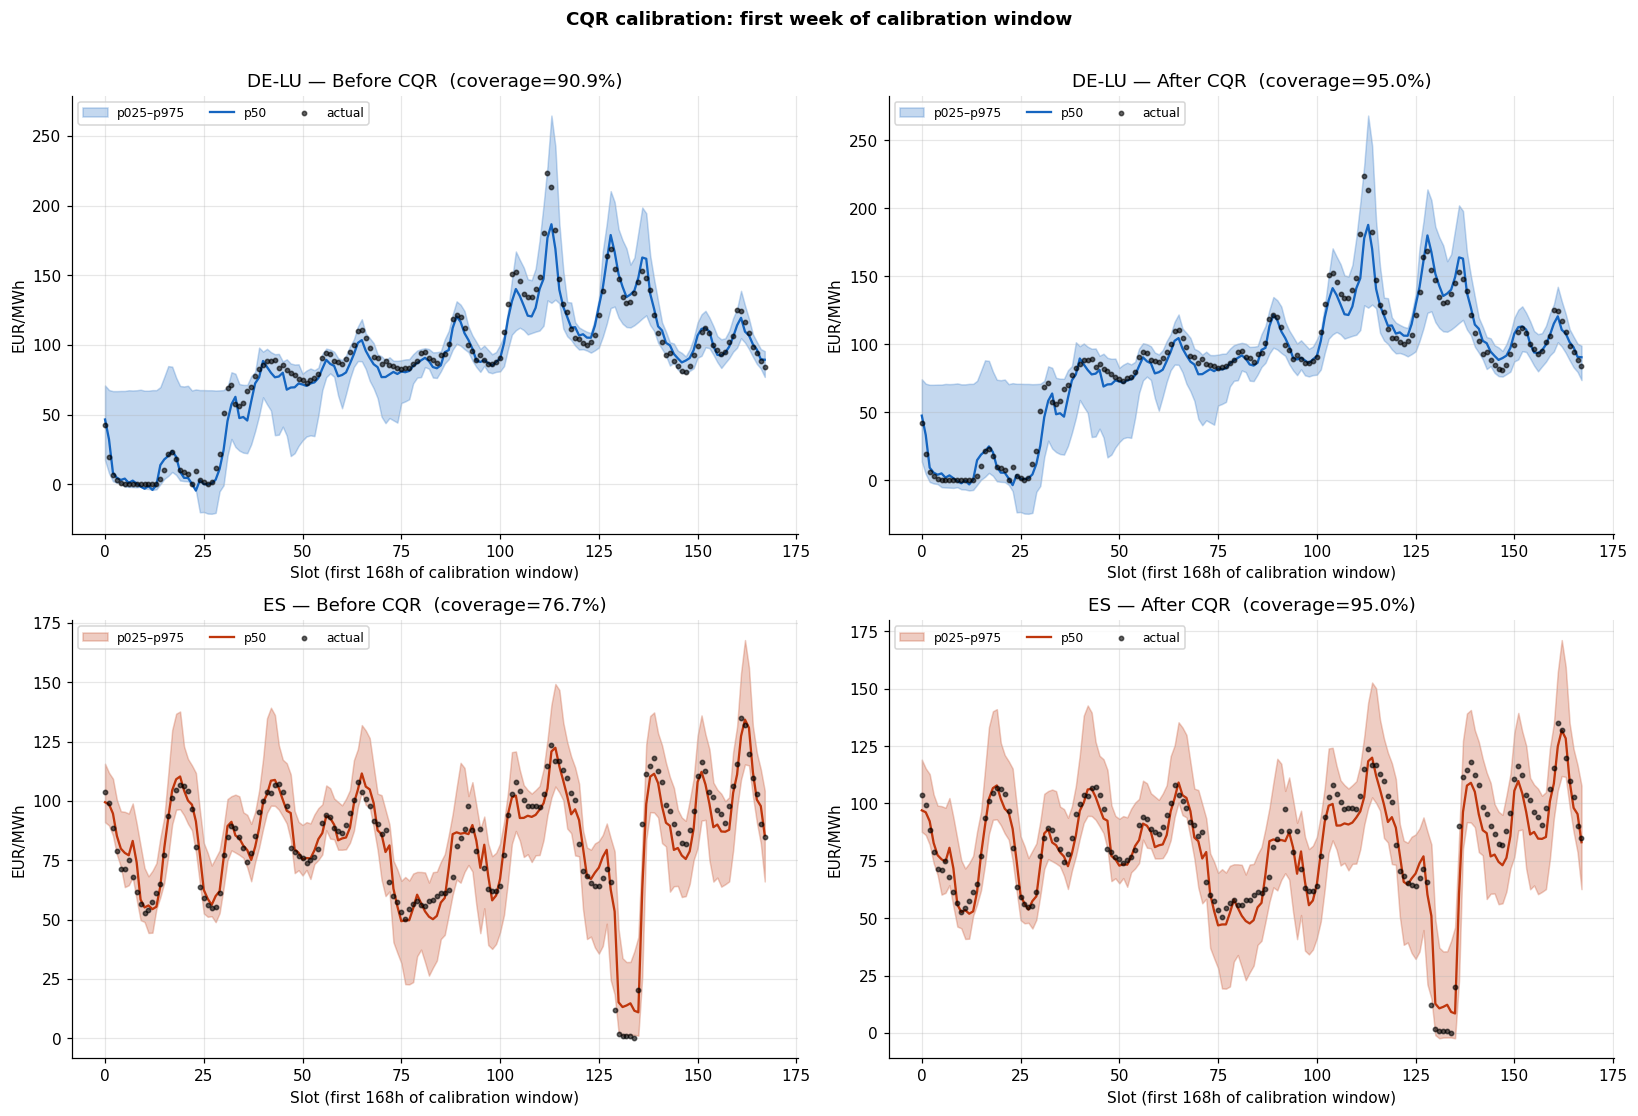

In [16]:
# Visual: calibration set actual vs bands, before and after CQR
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, zone in enumerate(ZONES):
    c    = cqr[zone]
    y    = c["y"]
    p025 = c["p025"]
    p50  = c["p50_raw"]
    p975 = c["p975"]
    q_iv = c["interval"]
    q_50 = c["p50"]
    idx  = np.arange(min(168, len(y)))   # first week for readability

    for j, (title, lo, mid, hi) in enumerate([
        ("Before CQR",  p025,       p50,        p975),
        ("After CQR",   p025-q_iv,  p50+q_50,   p975+q_iv),
    ]):
        ax = axes[i, j]
        ax.fill_between(idx, lo[idx], hi[idx], alpha=0.25, color=ZONE_COLORS[zone], label="p025–p975")
        ax.plot(idx, mid[idx], lw=1.5, color=ZONE_COLORS[zone], label="p50")
        ax.scatter(idx, y[idx], s=8, color="black", alpha=0.6, zorder=5, label="actual")
        cov = coverage(y, lo, hi)
        ax.set_title(f"{zone} — {title}  (coverage={cov:.1f}%)")
        ax.set_xlabel("Slot (first 168h of calibration window)")
        ax.set_ylabel("EUR/MWh")
        ax.legend(fontsize=8, ncol=3)

plt.suptitle("CQR calibration: first week of calibration window", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 8 · Feature importance — cross-zone comparison

LightGBM split count: number of times a feature was chosen to split a tree node.
More splits = more influence on predictions. Normalised to % of total splits.

**What to look for:**
- Lag features dominating: model is mostly autoregressive. Good baseline, but means
  exogenous signals (wind, load) need to earn their keep.
- `wind_generation` high in DE-LU, `solar_generation` high in ES: confirms market
  structure differences are being learned.
- `is_holiday` low by split count but critical for tail events — split count understates
  its importance on high-magnitude low-frequency events.
- `net_imports` (if in dataset): expect positive importance for DE-LU (interconnected),
  lower for ES (isolated).


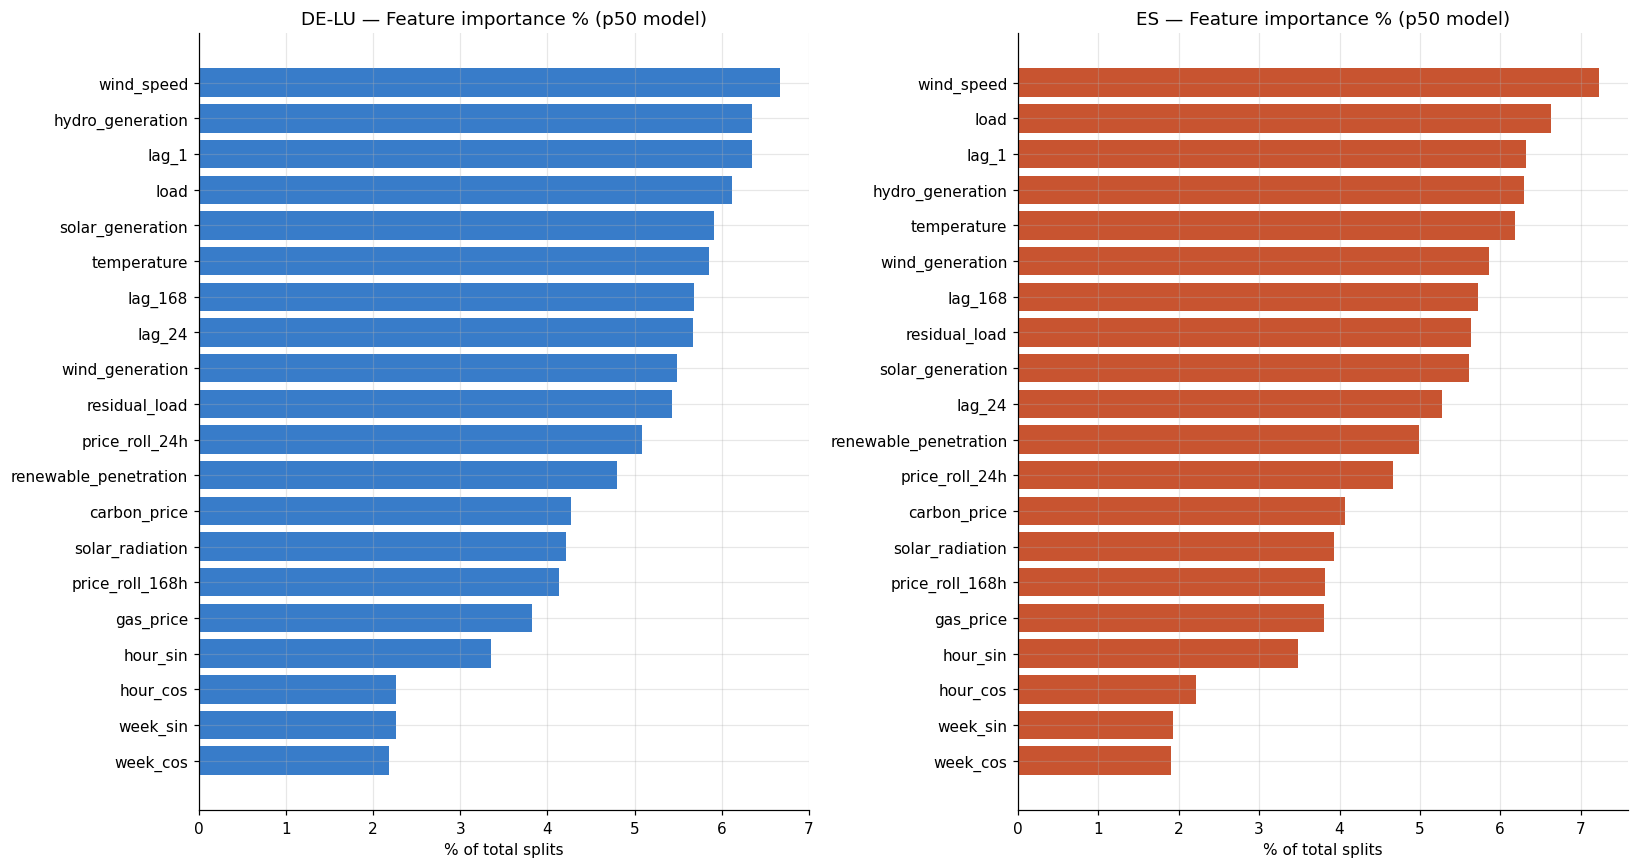

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
imp_data  = {}

for i, zone in enumerate(ZONES):
    m   = all_models[zone][0.45]
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    imp_data[zone] = (imp / imp.sum() * 100)
    top = imp_data[zone].sort_values().tail(20)
    ax  = axes[i]
    bars = ax.barh(top.index, top.values, color=ZONE_COLORS[zone], alpha=0.85, edgecolor="none")
    ax.set_title(f"{zone} — Feature importance % (p50 model)")
    ax.set_xlabel("% of total splits")

plt.tight_layout()
plt.show()


In [19]:
# Side-by-side delta: which features matter MORE in DE-LU vs ES
comparison = pd.DataFrame(imp_data).round(2)
comparison.columns = ["DE-LU %", "ES %"]
comparison["Δ DE-LU minus ES"] = (comparison["DE-LU %"] - comparison["ES %"]).round(2)
comparison = comparison.sort_values("Δ DE-LU minus ES", ascending=False)

print("Features that matter MORE in DE-LU (positive Δ):")
print(comparison[comparison["Δ DE-LU minus ES"] > 0].head(8).to_string())
print()
print("Features that matter MORE in ES (negative Δ):")
print(comparison[comparison["Δ DE-LU minus ES"] < 0].tail(8).to_string())


Features that matter MORE in DE-LU (positive Δ):
                  DE-LU %  ES %  Δ DE-LU minus ES
price_roll_24h       5.08  4.67              0.41
lag_24               5.67  5.28              0.39
week_sin             2.26  1.93              0.33
price_roll_168h      4.14  3.82              0.32
solar_generation     5.92  5.61              0.31
solar_radiation      4.21  3.93              0.28
week_cos             2.18  1.90              0.28
carbon_price         4.27  4.07              0.20

Features that matter MORE in ES (negative Δ):
                       DE-LU %  ES %  Δ DE-LU minus ES
weekday_cos               1.18  1.34             -0.16
renewable_penetration     4.79  4.99             -0.20
residual_load             5.43  5.64             -0.21
weekday_sin               1.50  1.82             -0.32
temperature               5.85  6.18             -0.33
wind_generation           5.49  5.85             -0.36
load                      6.12  6.64             -0.52
wind_speed    

## 9 · Error analysis — where the model fails and why

Focus on worst predictions: large absolute errors reveal structural model limitations.

**Known failure modes:**
- **Renewables-saturation events**: solar + wind surplus on holidays or weekends pushes
  prices to extreme negatives. Model underestimates magnitude (trained on pinball loss,
  which is median-honest and doesn't chase extremes).
- **Gas price shock hours**: sudden scarcity or market-wide gas outage. Model has gas_price
  as a daily feature; intra-day shocks are invisible.
- **Holiday timing edge cases**: `is_holiday` is a binary flag. A short holiday bridge
  (e.g. Thursday holiday + long weekend) creates multi-day patterns the model can't encode.


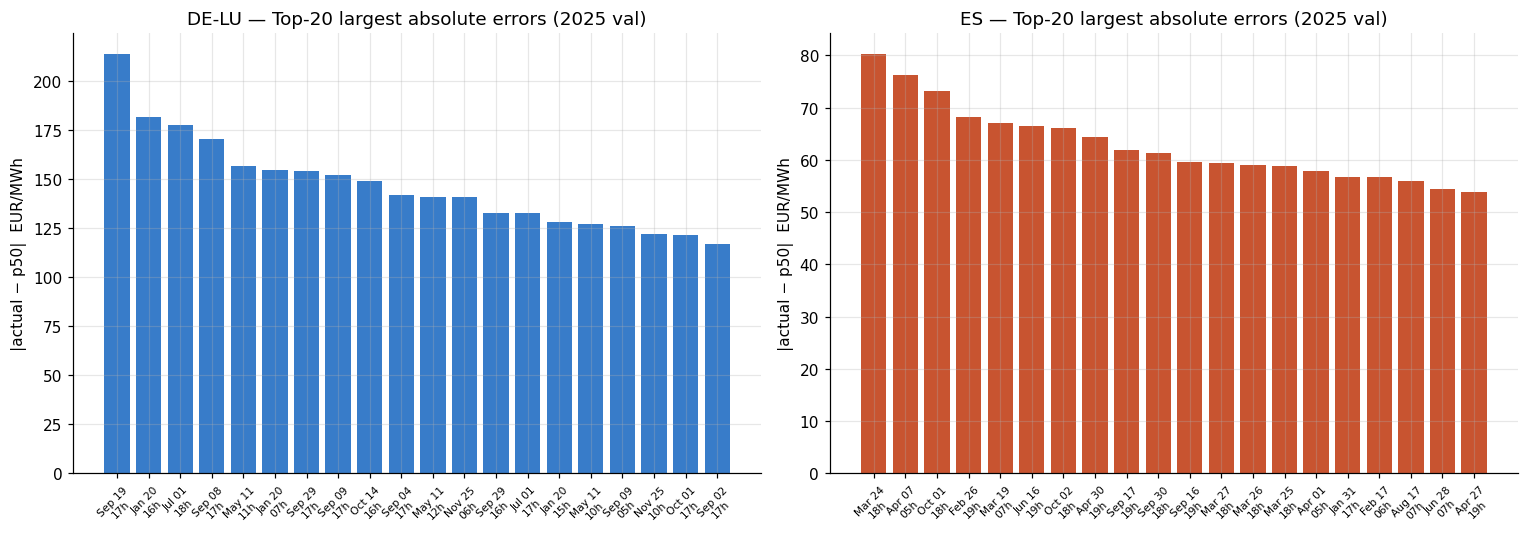

In [20]:
# Top-20 worst hours by absolute error in validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, zone in enumerate(ZONES):
    y   = all_val[zone]["actual"]
    p50 = pd.Series(all_val[zone]["preds"][0.45], index=y.index)
    err = (y - p50).abs().sort_values(ascending=False)
    top20 = err.head(20)

    ax = axes[i]
    ax.bar(range(20), top20.values, color=ZONE_COLORS[zone], alpha=0.85, edgecolor="none")
    ax.set_xticks(range(20))
    labels = [t.strftime("%b %d\n%Hh") for t in top20.index]
    ax.set_xticklabels(labels, fontsize=7, rotation=45)
    ax.set_title(f"{zone} — Top-20 largest absolute errors (2025 val)")
    ax.set_ylabel("|actual − p50|  EUR/MWh")

plt.tight_layout()
plt.show()


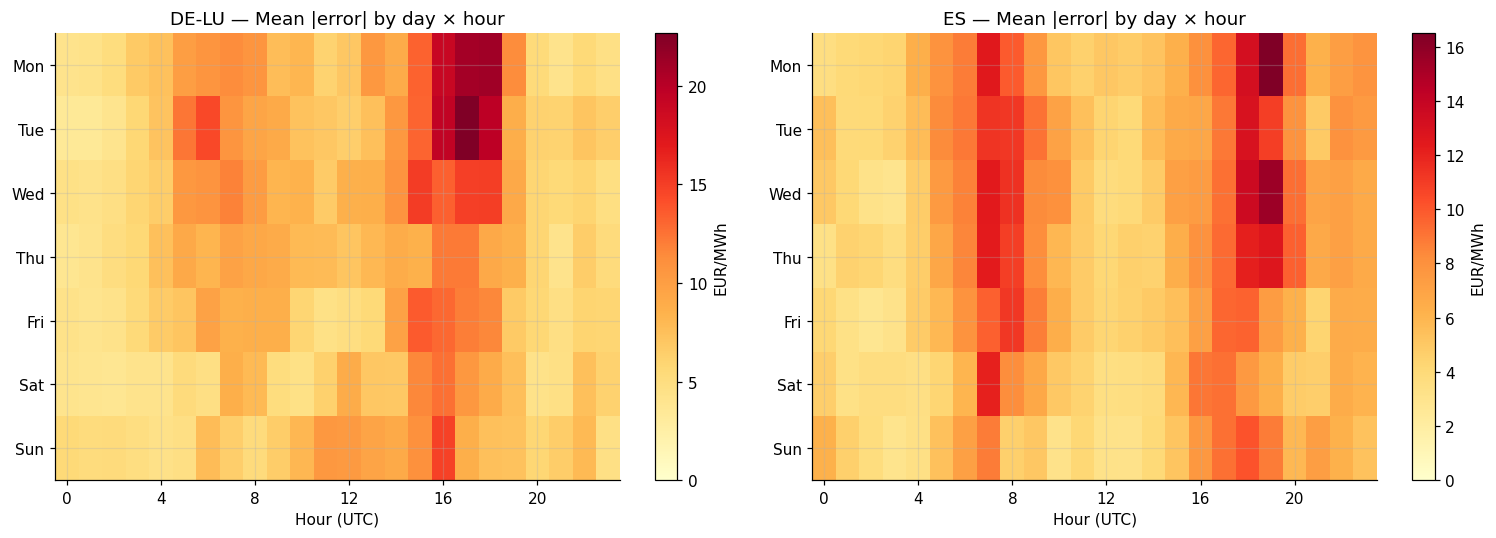

In [21]:
# Error by hour of day and day of week — heatmap
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, zone in enumerate(ZONES):
    y   = all_val[zone]["actual"]
    p50 = pd.Series(all_val[zone]["preds"][0.45], index=y.index)
    err = (y - p50).abs()

    pivot = pd.DataFrame({"err": err, "hour": err.index.hour, "dow": err.index.dayofweek})
    heat  = pivot.groupby(["dow", "hour"])["err"].mean().unstack()

    ax = axes[i]
    im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd", vmin=0)
    ax.set_yticks(range(7))
    ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    ax.set_xticks(range(0, 24, 4))
    ax.set_xlabel("Hour (UTC)")
    ax.set_title(f"{zone} — Mean |error| by day × hour")
    plt.colorbar(im, ax=ax, label="EUR/MWh")

plt.tight_layout()
plt.show()


## 10 · Eval-window forecast — May 8–9 2026

**Context:**
- Friday evening (May 8) into Saturday (May 9)
- Weekend → lower industrial demand → solar saturation risk midday
- May 9 is not a public holiday in DE or ES
- lag_168 = same hour last Friday (May 1 = Labor Day in both DE and ES — negative prices likely)
  → could bias some lag features low
- Lag-gap fill: lag_1 and lag_24 for future slots are populated recursively from model's own
  calibrated p50. lag_168 is fully in the historical dataset.


In [22]:
_ZONE_COUNTRY = {"DE-LU": "DE", "ES": "ES"}

def build_eval_row(zdf, ref, ts, predicted_p50, cal):
    row      = {}
    same_hw  = ref[(ref.index.hour == ts.hour) & (ref.index.dayofweek == ts.dayofweek)]
    proxy_cols = [c for c in [
        "load", "wind_generation", "solar_generation", "hydro_generation",
        "temperature", "wind_speed", "solar_radiation",
        "residual_load", "renewable_penetration", "net_imports",
    ] if c in ref.columns]
    for col in proxy_cols:
        row[col] = float(same_hw[col].mean()) if len(same_hw) > 0 else float(ref[col].mean())

    row["gas_price"]    = float(ref["gas_price"].iloc[-1])
    row["carbon_price"] = float(ref["carbon_price"].iloc[-1])

    woy = ts.isocalendar()[1]
    row["hour_sin"]    = np.sin(2*np.pi*ts.hour/24);      row["hour_cos"]    = np.cos(2*np.pi*ts.hour/24)
    row["weekday_sin"] = np.sin(2*np.pi*ts.dayofweek/7);  row["weekday_cos"] = np.cos(2*np.pi*ts.dayofweek/7)
    row["month_sin"]   = np.sin(2*np.pi*(ts.month-1)/12); row["month_cos"]   = np.cos(2*np.pi*(ts.month-1)/12)
    row["week_sin"]    = np.sin(2*np.pi*(woy-1)/52);      row["week_cos"]    = np.cos(2*np.pi*(woy-1)/52)
    row["is_holiday"]  = int(ts.date() in cal)

    def lkp(lag_ts, fb):
        if lag_ts in zdf.index: return float(zdf.loc[lag_ts, "price"])
        if lag_ts in predicted_p50: return predicted_p50[lag_ts]
        return float(ref[fb].mean())

    row["lag_168"] = lkp(ts - pd.Timedelta(hours=168), "lag_168")
    row["lag_24"]  = lkp(ts - pd.Timedelta(hours=24),  "lag_24")
    row["lag_1"]   = lkp(ts - pd.Timedelta(hours=1),   "lag_1")
    row["price_roll_24h"]  = float(zdf["price"].iloc[-24:].mean())
    row["price_roll_168h"] = float(zdf["price"].iloc[-168:].mean())
    return row

eval_start = pd.Timestamp("2026-05-08 17:00", tz="UTC")
eval_end   = pd.Timestamp("2026-05-09 22:00", tz="UTC")
eval_idx   = pd.date_range(eval_start, eval_end, freq="h")

zone_preds = {}
for zone in ZONES:
    zdf = df.xs(zone, level="zone").sort_index()
    ref = zdf[eval_start - pd.Timedelta(weeks=4) : eval_start - pd.Timedelta(hours=1)]
    cal = hdays.country_holidays(_ZONE_COUNTRY[zone])
    q_iv, q_50 = cqr[zone]["interval"], cqr[zone]["p50"]

    predicted_p50 = {}
    p025_l, p50_l, p975_l = [], [], []

    for ts in eval_idx:
        row  = build_eval_row(zdf, ref, ts, predicted_p50, cal)
        x    = pd.DataFrame([row])[FEATURES]
        p025 = float(all_models[zone][0.025].predict(x)[0])
        p50  = float(all_models[zone][0.45].predict(x)[0])
        p975 = float(all_models[zone][0.975].predict(x)[0])
        p025 = min(p025, p50); p975 = max(p975, p50)
        p50  = p50  + q_50
        p025 = p025 - q_iv;    p975 = p975 + q_iv
        p025 = min(p025, p50); p975 = max(p975, p50)
        predicted_p50[ts] = p50
        p025_l.append(p025); p50_l.append(p50); p975_l.append(p975)

    zone_preds[zone] = {"p025": p025_l, "p50": p50_l, "p975": p975_l}
    print(f"{zone}: mean p50={np.mean(p50_l):.1f}  band={np.mean(np.array(p975_l)-np.array(p025_l)):.1f} EUR/MWh")


DE-LU: mean p50=79.9  band=50.4 EUR/MWh
ES: mean p50=58.2  band=33.3 EUR/MWh


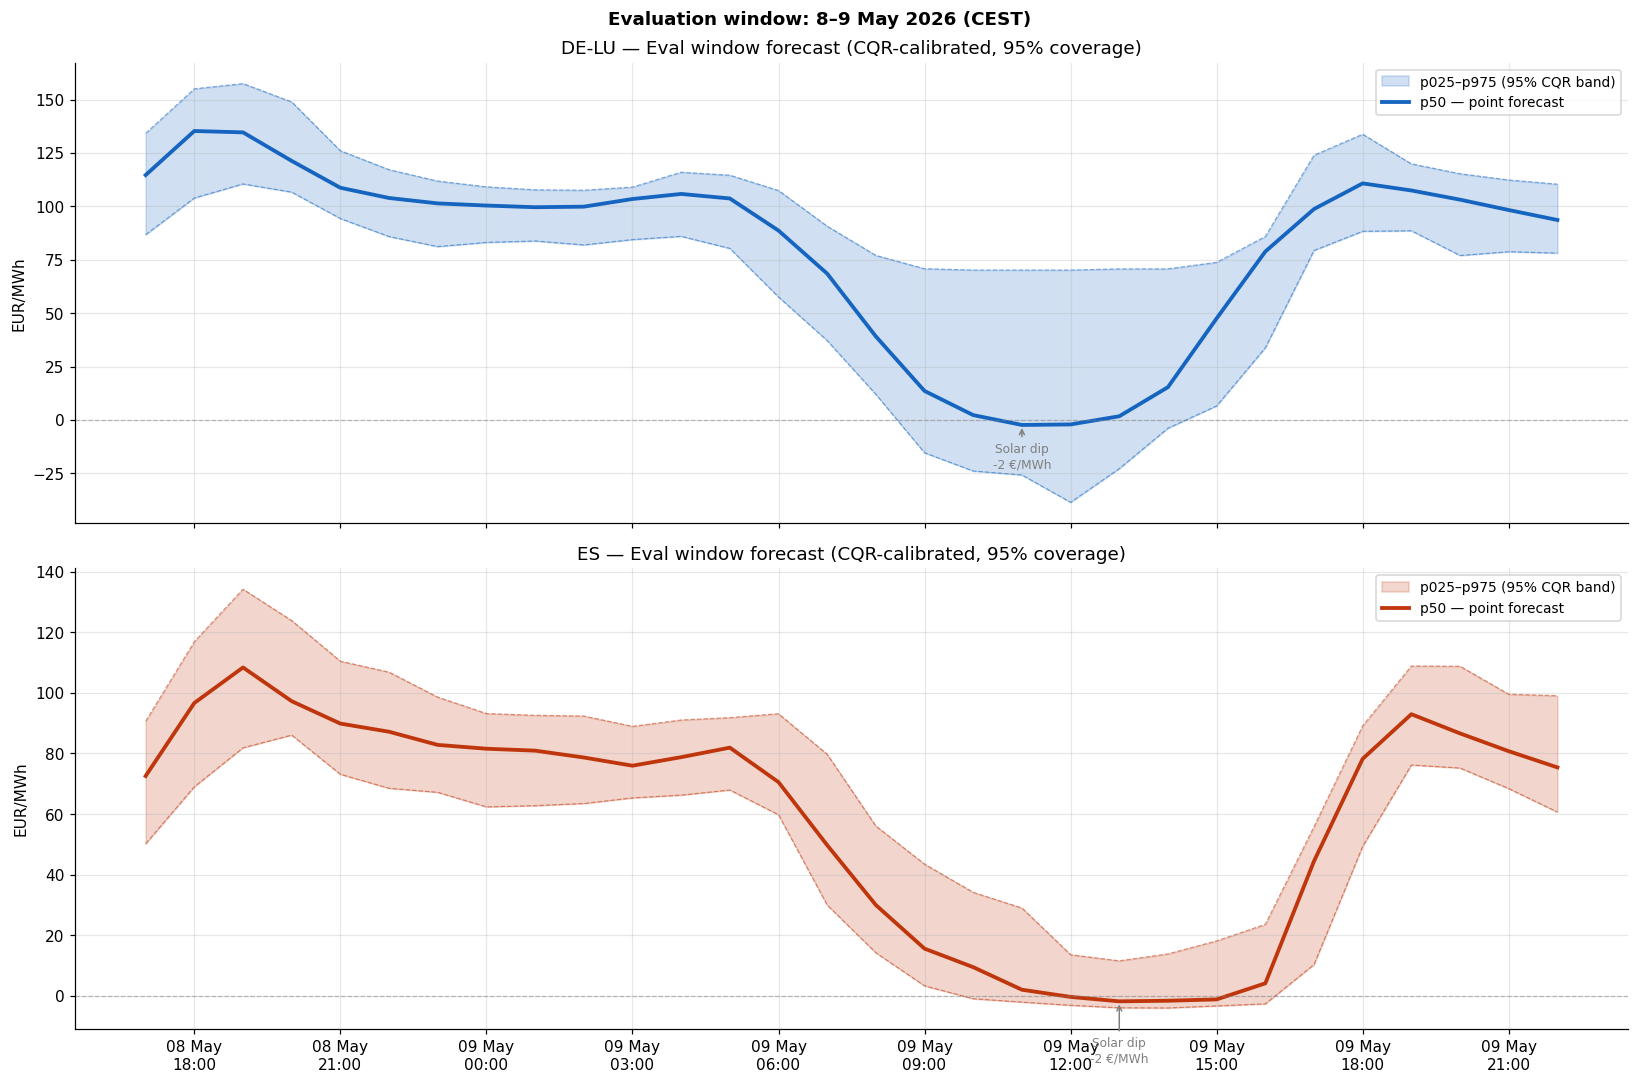

In [23]:
cest = eval_idx.tz_convert("Europe/Berlin")
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for i, zone in enumerate(ZONES):
    ax   = axes[i]
    p025 = zone_preds[zone]["p025"]
    p50  = zone_preds[zone]["p50"]
    p975 = zone_preds[zone]["p975"]
    c    = ZONE_COLORS[zone]

    ax.fill_between(cest, p025, p975, alpha=0.2, color=c, label="p025–p975 (95% CQR band)")
    ax.plot(cest, p025, lw=0.8, color=c, alpha=0.5, linestyle="--")
    ax.plot(cest, p975, lw=0.8, color=c, alpha=0.5, linestyle="--")
    ax.plot(cest, p50,  lw=2.5, color=c, label="p50 — point forecast")
    ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.5)

    # Annotate solar dip
    min_idx = np.argmin(p50)
    ax.annotate(f"Solar dip\n{p50[min_idx]:.0f} €/MWh",
                xy=(cest[min_idx], p50[min_idx]),
                xytext=(cest[min_idx], p50[min_idx] - 20),
                arrowprops=dict(arrowstyle="->", color="gray"),
                fontsize=8, ha="center", color="gray")

    ax.set_title(f"{zone} — Eval window forecast (CQR-calibrated, 95% coverage)")
    ax.set_ylabel("EUR/MWh")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3)))

plt.suptitle("Evaluation window: 8–9 May 2026 (CEST)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [24]:
# Tabular forecast with annotations
ts_cest = eval_idx.tz_convert("Europe/Berlin")
out = pd.DataFrame({
    "timestamp": [t.strftime("%d %b %H:%M CEST") for t in ts_cest],
    "DE-LU p025": [f"{v:6.1f}" for v in zone_preds["DE-LU"]["p025"]],
    "DE-LU p50" : [f"{v:6.1f}" for v in zone_preds["DE-LU"]["p50"]],
    "DE-LU p975": [f"{v:6.1f}" for v in zone_preds["DE-LU"]["p975"]],
    "ES p025"   : [f"{v:6.1f}" for v in zone_preds["ES"]["p025"]],
    "ES p50"    : [f"{v:6.1f}" for v in zone_preds["ES"]["p50"]],
    "ES p975"   : [f"{v:6.1f}" for v in zone_preds["ES"]["p975"]],
})
print(out.to_string(index=False))


        timestamp DE-LU p025 DE-LU p50 DE-LU p975 ES p025 ES p50 ES p975
08 May 19:00 CEST       86.7     114.6      134.2    50.2   72.6    90.6
08 May 20:00 CEST      103.9     135.3      155.0    69.0   96.7   116.9
08 May 21:00 CEST      110.5     134.6      157.5    81.9  108.4   134.2
08 May 22:00 CEST      106.7     121.3      148.9    86.1   97.3   123.9
08 May 23:00 CEST       94.3     108.7      126.0    73.1   89.9   110.5
09 May 00:00 CEST       85.9     103.9      117.2    68.5   87.2   106.8
09 May 01:00 CEST       81.2     101.4      111.8    67.2   82.8    98.6
09 May 02:00 CEST       83.1     100.4      109.1    62.4   81.6    93.2
09 May 03:00 CEST       83.8      99.6      107.7    62.8   80.9    92.6
09 May 04:00 CEST       81.9      99.9      107.5    63.5   78.7    92.4
09 May 05:00 CEST       84.4     103.4      109.0    65.3   76.0    88.9
09 May 06:00 CEST       86.0     105.8      116.0    66.2   78.8    91.0
09 May 07:00 CEST       80.3     103.7      114.6  

## 11 · Long-term seasonal forecast — 2 years

For horizons beyond ~7 days, granular weather/generation signals are unavailable.
Methodology:
1. **Seasonal profile** — empirical per-(month × hour) mean and 2.5/97.5th percentile
   from 2022–2024 training data
2. **Trend** — linear year-over-year price drift estimated from annual averages
3. **Uncertainty** — direct historical quantile bands (no parametric assumption)

At 2-year horizon, this is honest: uncertainty is the full historical spread at each
seasonal slot. Infrastructure financing models use exactly this kind of scenario envelope.


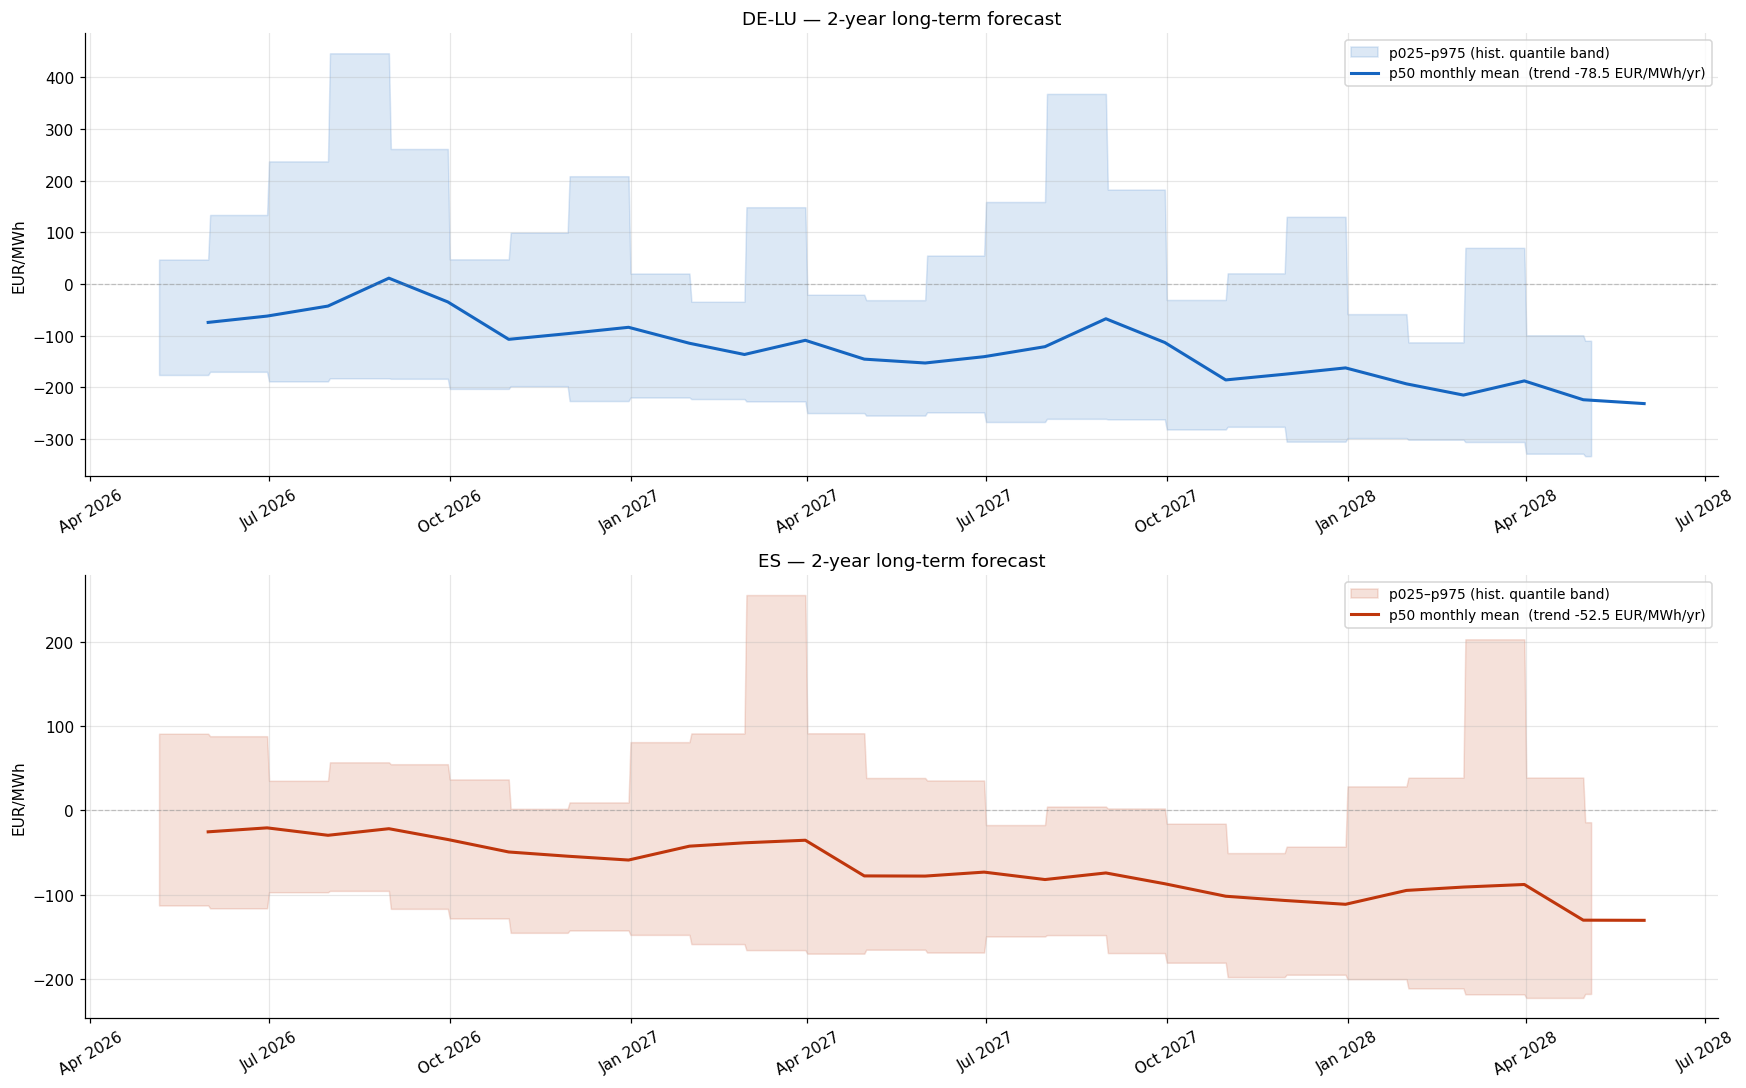

In [25]:
def long_term_forecast(df, zone, start="2026-05-06", periods=17520):
    zdf   = df.xs(zone, level="zone").sort_index()
    data  = zdf["2022":"2024"].copy()
    data["month"] = data.index.month
    data["hour"]  = data.index.hour

    profile = (
        data.groupby(["month", "hour"])["price"]
        .agg(mean="mean", q025=lambda x: x.quantile(0.025), q975=lambda x: x.quantile(0.975))
        .reset_index()
        .set_index(["month", "hour"])
    )
    by_year  = data.groupby(data.index.year)["price"].mean()
    trend    = float(np.polyfit(by_year.index.astype(float), by_year.values, 1)[0])
    base_yr  = float(by_year.index[-1])

    future = pd.date_range(start, periods=periods, freq="h", tz="UTC")
    p50, p025, p975 = [], [], []
    for ts in future:
        key = (ts.month, ts.hour)
        row = profile.loc[key] if key in profile.index else None
        adj = trend * ((ts.year - base_yr) + (ts.month - 1) / 12)
        if row is not None:
            p50.append(float(row["mean"]) + adj)
            p025.append(float(row["q025"]) + adj)
            p975.append(float(row["q975"]) + adj)
        else:
            mid = profile["mean"].mean() + adj
            p50.append(mid); p025.append(mid-30); p975.append(mid+30)

    return pd.DataFrame({"p025": p025, "p50": p50, "p975": p975}, index=future)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for i, zone in enumerate(ZONES):
    _, trend, base_yr = (lambda d, z: (
        d.xs(z, level="zone")["2022":"2024"],
        float(np.polyfit(
            d.xs(z, level="zone")["2022":"2024"].groupby(d.xs(z, level="zone")["2022":"2024"].index.year)["price"].mean().index.astype(float),
            d.xs(z, level="zone")["2022":"2024"].groupby(d.xs(z, level="zone")["2022":"2024"].index.year)["price"].mean().values, 1)[0]),
        float(d.xs(z, level="zone")["2022":"2024"].index.year.max())
    ))(df, zone)

    lt       = long_term_forecast(df, zone)
    lt_daily = lt.resample("D").mean()
    lt_mo    = lt.resample("ME").mean()
    ax       = axes[i]
    ax.fill_between(lt_daily.index, lt_daily["p025"], lt_daily["p975"],
                    alpha=0.15, color=ZONE_COLORS[zone], label="p025–p975 (hist. quantile band)")
    ax.plot(lt_mo.index, lt_mo["p50"], lw=2, color=ZONE_COLORS[zone],
            label=f"p50 monthly mean  (trend {trend:+.1f} EUR/MWh/yr)")
    ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.4)
    ax.set_title(f"{zone} — 2-year long-term forecast")
    ax.set_ylabel("EUR/MWh")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()
